# Implicit Euler PDE Solver: Original Parameters

Solve the full HJB PDE (Eq. 1) with the paper's original η = 10⁻⁹ using
fully implicit Euler with policy iteration (Howard's algorithm).

**Key ingredients:**
- **Monotone (M-matrix) differencing** for the hedging advection term.
  Ensures diagonal dominance and non-positive off-diagonals, required
  for policy iteration convergence.
- **Overflow protection** in the Lambert W computation. Prevents NaN
  from extreme quoting momentum values.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from src.model import (
    build_paper_example_params, restrict_currencies, canon_pair, BP,
)
from src.policy import run_multicurrency_mm
from src.pde import (
    solve_hjb_explicit,
    terminal_condition,
    build_pde_spec,
)

mp = restrict_currencies(build_paper_example_params(), ["USD", "EUR"])
eurusd_key = canon_pair("EUR", "USD")

print(f"Currencies: {mp.currencies}")
print(f"T = {mp.T_days} days, gamma = {mp.gamma}")
print(f"eta (original): {mp.pairs[eurusd_key].eta:.2e}")
print(f"psi:            {mp.pairs[eurusd_key].psi:.2e}")

Currencies: ['USD', 'EUR']
T = 0.05 days, gamma = 20.0
eta (original): 1.00e-09
psi:            1.00e-05


In [4]:
# Grid
Y_MAX = 150
DY = 1.0
d = len(mp.currencies)

y_grids = [np.arange(-Y_MAX, Y_MAX + DY, DY) for _ in range(d)]
idx_origin = len(y_grids[0]) // 2
y_eur = y_grids[1]

print(f"Grid: [{-Y_MAX}, {Y_MAX}] M$, dy={DY}, points/axis={len(y_grids[0])}")
print(f"Total grid points: {len(y_grids[0])**d}")

# ODE reference (original eta, for comparison)
ode_res = run_multicurrency_mm(mp)
A0 = ode_res.A0
B0 = ode_res.B0
print(f"\nODE A0[EUR,EUR] = {A0[1,1]:.6e}")
print(f"ODE B0 = {B0}")

Grid: [-150, 150] M$, dy=1.0, points/axis=301
Total grid points: 90601

ODE A0[EUR,EUR] = 9.378559e-07
ODE B0 = [0. 0.]


## 1. Solve PDE with original η

Fully implicit Euler with policy iteration. Monotone differencing for the hedging advection term ensures the M-matrix property. PI tolerance is set to 1e-4. Most time steps converge in 2 to 7 iterations. A handful of late steps hit `pi_max_iter = 50` with rel_diff plateauing around 1 to 3e-4, but the value function changes negligibly past iteration ~5 in those cases.

In [5]:
import warnings
import scipy.sparse.linalg

from src.pde import (
    build_pde_spec, terminal_condition, compute_gradient,
    extract_quoting_controls, extract_hedging_controls,
    assemble_implicit_system,
)

N_STEPS = 20
PI_TOL = 1e-4
PI_MAX_ITER = 50

T = mp.T_days
dt = T / N_STEPS

spec = build_pde_spec(y_grids, mp)
kappa = mp.kappa if mp.kappa is not None else np.zeros((d, d))
theta = terminal_condition(y_grids, kappa)
grid_shape = theta.shape

print(f"dt = {dt:.4e} days, {N_STEPS} steps")
print(f"eta (original) = {mp.pairs[eurusd_key].eta:.2e}")
print(f"pi_tol = {PI_TOL:.0e}, pi_max_iter = {PI_MAX_ITER}")
print()

print(f"{'Step':>4s}  {'PI':>3s}  {'rel_diff':>10s}  {'theta_min':>12s}  {'theta_max':>12s}  {'theta(0,0)':>12s}")
print("-" * 75)

for m in range(N_STEPS):
    theta_old = theta.copy()

    for k_pi in range(PI_MAX_ITER):
        grad = compute_gradient(theta, spec.dy_list)
        q_ctrl = extract_quoting_controls(theta, spec)
        h_ctrl = extract_hedging_controls(grad, spec.y_grids, spec)

        A, source = assemble_implicit_system(q_ctrl, h_ctrl, spec, dt)
        b = theta_old.ravel() + source

        theta_new = scipy.sparse.linalg.spsolve(A, b).reshape(grid_shape)

        abs_diff = np.max(np.abs(theta_new - theta))
        scale = max(1.0, np.max(np.abs(theta_new)))
        rel_diff = abs_diff / scale
        theta = theta_new

        if rel_diff < PI_TOL:
            break

    print(f"{m:4d}  {k_pi+1:3d}  {rel_diff:10.2e}  {theta.min():12.4e}  "
          f"{theta.max():12.4e}  {theta[idx_origin, idx_origin]:12.6e}")

print(f"\nCompleted {N_STEPS} steps.")
print(f"theta_0 at origin: {theta[idx_origin, idx_origin]:.6e}")
print(f"theta_0 range: [{theta.min():.4e}, {theta.max():.4e}]")

dt = 2.5000e-03 days, 20 steps
eta (original) = 1.00e-09
pi_tol = 1e-04, pi_max_iter = 50

Step   PI    rel_diff     theta_min     theta_max    theta(0,0)
---------------------------------------------------------------------------
   0    7    6.68e-05   -3.6000e-02    5.8583e-04  5.858252e-04
   1    4    5.32e-05   -7.2000e-02    1.1247e-03  1.124664e-03
   2    3    5.35e-05   -1.0800e-01    1.6534e-03  1.653356e-03
   3    2    4.98e-05   -1.4400e-01    2.1797e-03  2.179715e-03
   4    2    3.94e-05   -1.8000e-01    2.7055e-03  2.705525e-03
   5    2    4.78e-05   -2.1600e-01    3.2312e-03  3.231206e-03
   6    2    8.88e-05   -2.5200e-01    3.7569e-03  3.756856e-03
   7    3    8.71e-05   -2.8800e-01    4.2825e-03  4.282498e-03
   8    4    9.24e-05   -3.2400e-01    4.8081e-03  4.808138e-03
   9    4    8.03e-05   -3.6000e-01    5.3338e-03  5.333778e-03
  10    3    9.42e-05   -3.9600e-01    5.8594e-03  5.859418e-03
  11    2    7.41e-05   -4.3200e-01    6.3851e-03  6.385058e-03
 

## 2. Compare PDE vs ODE along EUR inventory axis

The PDE solution should agree with the ODE ansatz $\hat\theta = -y^\top A_0 y - y^\top B_0 - C_0$
for moderate inventory, and diverge at large $|y|$ where the quadratic
approximation of the Hamiltonian breaks down.

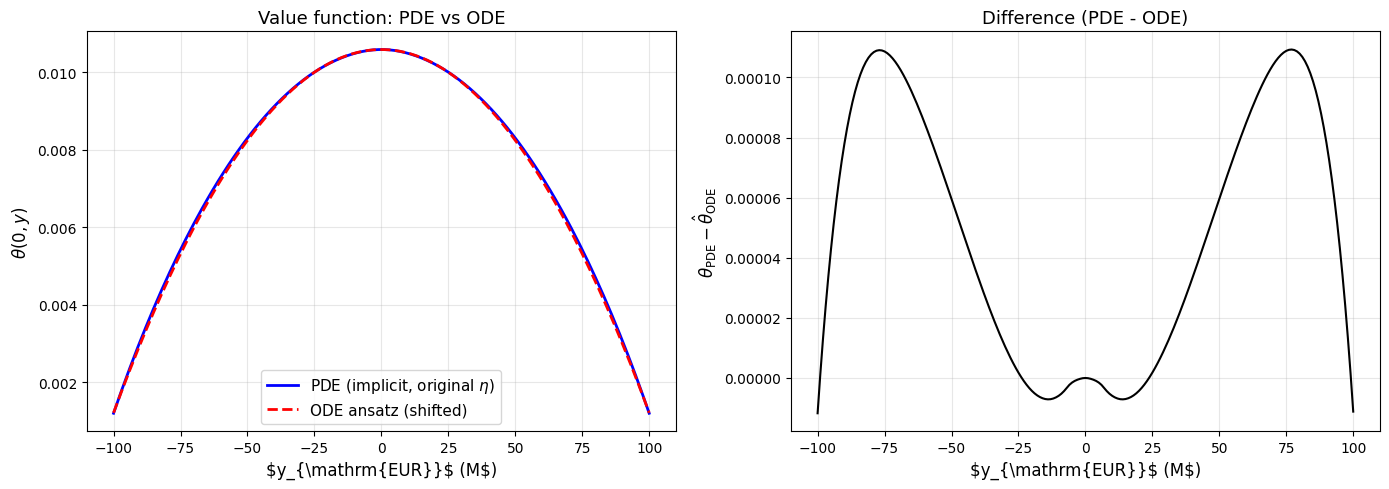

theta_PDE at origin:  1.059018e-02
theta_ODE at origin:  1.059018e-02  (shifted to match)
Max |diff| in [-100, 100]: 1.092760e-04


In [6]:
# Slice along EUR axis (y_USD = 0)
theta_pde = theta  # from the solver cell above
slice_pde = theta_pde[idx_origin, :]

# ODE ansatz: theta_hat = -y^T A0 y - y^T B0 - C0
# Along y_USD=0: theta_hat = -A0[1,1] * y_EUR^2 - B0[1] * y_EUR - C0
# C0 is not directly available; shift to match at origin
theta_ode_raw = -A0[1, 1] * y_eur**2 - B0[1] * y_eur
C0_shift = slice_pde[idx_origin] - theta_ode_raw[idx_origin]
theta_ode = theta_ode_raw + C0_shift

roi = np.abs(y_eur) <= 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(y_eur[roi], slice_pde[roi], 'b-', linewidth=2, label='PDE (implicit, original $\\eta$)')
ax1.plot(y_eur[roi], theta_ode[roi], 'r--', linewidth=2, label='ODE ansatz (shifted)')
ax1.set_xlabel('$y_{\\mathrm{EUR}}$ (M$)', fontsize=12)
ax1.set_ylabel('$\\theta(0, y)$', fontsize=12)
ax1.set_title('Value function: PDE vs ODE', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

diff = slice_pde[roi] - theta_ode[roi]
ax2.plot(y_eur[roi], diff, 'k-', linewidth=1.5)
ax2.set_xlabel('$y_{\\mathrm{EUR}}$ (M$)', fontsize=12)
ax2.set_ylabel('$\\theta_{\\mathrm{PDE}} - \\hat\\theta_{\\mathrm{ODE}}$', fontsize=12)
ax2.set_title('Difference (PDE - ODE)', fontsize=13)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"theta_PDE at origin:  {slice_pde[idx_origin]:.6e}")
print(f"theta_ODE at origin:  {theta_ode[idx_origin]:.6e}  (shifted to match)")
print(f"Max |diff| in [-100, 100]: {np.max(np.abs(diff)):.6e}")

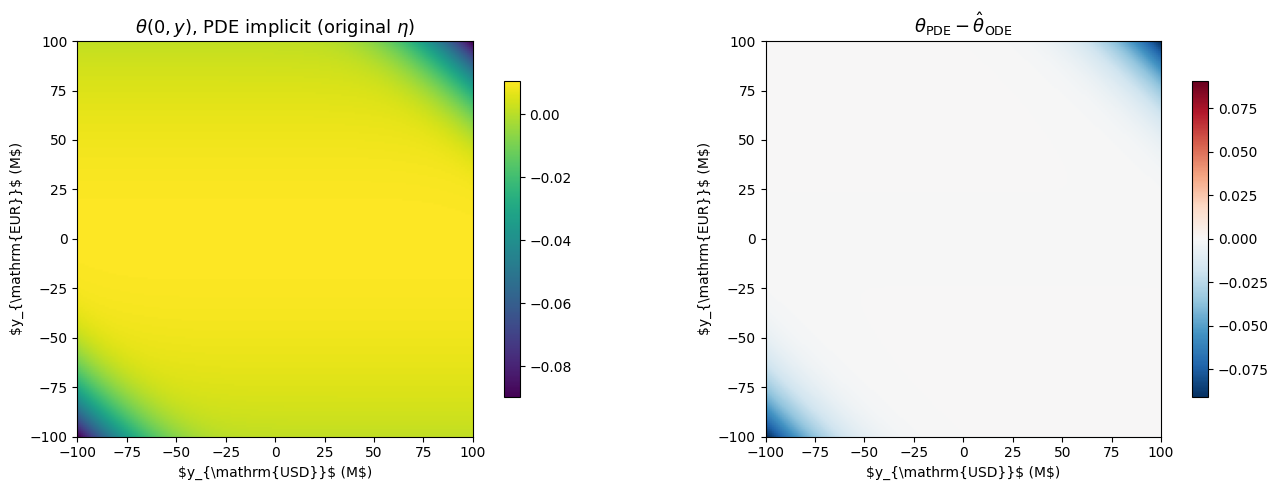

In [7]:
# 2D heatmap
roi_idx = np.abs(y_grids[0]) <= 100
roi_2d = np.ix_(roi_idx, roi_idx)
y_roi = y_grids[0][roi_idx]
extent = [y_roi[0], y_roi[-1], y_roi[0], y_roi[-1]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1 = ax1.imshow(theta_pde[roi_2d].T, origin='lower', extent=extent,
                  aspect='equal', cmap='viridis')
ax1.set_xlabel('$y_{\\mathrm{USD}}$ (M$)')
ax1.set_ylabel('$y_{\\mathrm{EUR}}$ (M$)')
ax1.set_title('$\\theta(0, y)$, PDE implicit (original $\\eta$)', fontsize=13)
plt.colorbar(im1, ax=ax1, shrink=0.8)

# ODE ansatz on full 2D grid
Y_USD, Y_EUR = np.meshgrid(y_grids[0], y_grids[1], indexing='ij')
theta_ode_2d = -(A0[0,0]*Y_USD**2 + 2*A0[0,1]*Y_USD*Y_EUR + A0[1,1]*Y_EUR**2) \
               - (B0[0]*Y_USD + B0[1]*Y_EUR) + C0_shift

diff_2d = theta_pde[roi_2d] - theta_ode_2d[roi_2d]
vabs = max(abs(diff_2d.min()), abs(diff_2d.max()))
if vabs < 1e-15:
    vabs = 1.0  # avoid zero range
im2 = ax2.imshow(diff_2d.T, origin='lower', extent=extent,
                  aspect='equal', cmap='RdBu_r',
                  vmin=-vabs, vmax=vabs)
ax2.set_xlabel('$y_{\\mathrm{USD}}$ (M$)')
ax2.set_ylabel('$y_{\\mathrm{EUR}}$ (M$)')
ax2.set_title('$\\theta_{\\mathrm{PDE}} - \\hat\\theta_{\\mathrm{ODE}}$', fontsize=13)
plt.colorbar(im2, ax=ax2, shrink=0.8)

fig.tight_layout()
plt.show()